# پیش‌بینی Ship Mode سفارش‌ها

هدف: با استفاده از ویژگی‌های هر سفارش (Sales, Quantity, Discount, Market, Region, OrderPriority, Segment, Category, SubCategory, Profit)، مقدار `ShipMode` را پیش‌بینی می‌کنیم.

این یک مسئله‌ی **طبقه‌بندی چندکلاسه (Multi-class Classification)** با ۴ کلاس هدف است:
- Standard Class
- Second Class
- First Class
- Same Day

چند الگوریتم مختلف آموزش داده و با هم مقایسه می‌شوند تا بهترین مدل انتخاب شود.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (8, 5)
np.random.seed(42)


## ۱. بارگذاری و بررسی اولیه‌ی داده‌ها

In [2]:
df = pd.read_csv('orders.csv')
if df.columns[0].startswith('Unnamed'):
    df = df.drop(columns=[df.columns[0]])

print("Shape:", df.shape)
df.head()


Shape: (46690, 11)


,Sales,Quantity,Discount,Market,Region,OrderPriority,Segment,Category,SubCategory,ShipMode,Profit
0,13.08,3,0.0,LATAM,North,Medium,Consumer,Office Supplies,Labels,Standard Class,4.56
1,263.92,2,0.0,LATAM,North,Medium,Consumer,Office Supplies,Storage,Standard Class,5.24
2,300.72,14,0.0,LATAM,North,High,Corporate,Office Supplies,Supplies,First Class,129.08
3,138.18,7,0.0,LATAM,North,High,Corporate,Office Supplies,Supplies,First Class,53.76
4,90.80,4,0.0,LATAM,North,High,Corporate,Office Supplies,Supplies,First Class,31.76


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 46690 entries, 0 to 46689
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales          46690 non-null  float64
 1   Quantity       46690 non-null  int64  
 2   Discount       46690 non-null  float64
 3   Market         46690 non-null  str    
 4   Region         46690 non-null  str    
 5   OrderPriority  46690 non-null  str    
 6   Segment        46690 non-null  str    
 7   Category       46690 non-null  str    
 8   SubCategory    46690 non-null  str    
 9   ShipMode       46690 non-null  str    
 10  Profit         46690 non-null  float64
dtypes: float64(3), int64(1), str(7)
memory usage: 3.9 MB


In [4]:
print("مقادیر خالی:")
print(df.isnull().sum())
print()
print("توزیع کلاس هدف (ShipMode):")
print(df['ShipMode'].value_counts())
print()
print("درصد هر کلاس:")
print((df['ShipMode'].value_counts(normalize=True) * 100).round(2))


مقادیر خالی:
Sales            0
Quantity         0
Discount         0
Market           0
Region           0
OrderPriority    0
Segment          0
Category         0
SubCategory      0
ShipMode         0
Profit           0
dtype: int64

توزیع کلاس هدف (ShipMode):
ShipMode
Standard Class    28128
Second Class       9355
First Class        6757
Same Day           2450
Name: count, dtype: int64

درصد هر کلاس:
ShipMode
Standard Class    60.24
Second Class      20.04
First Class       14.47
Same Day           5.25
Name: proportion, dtype: float64


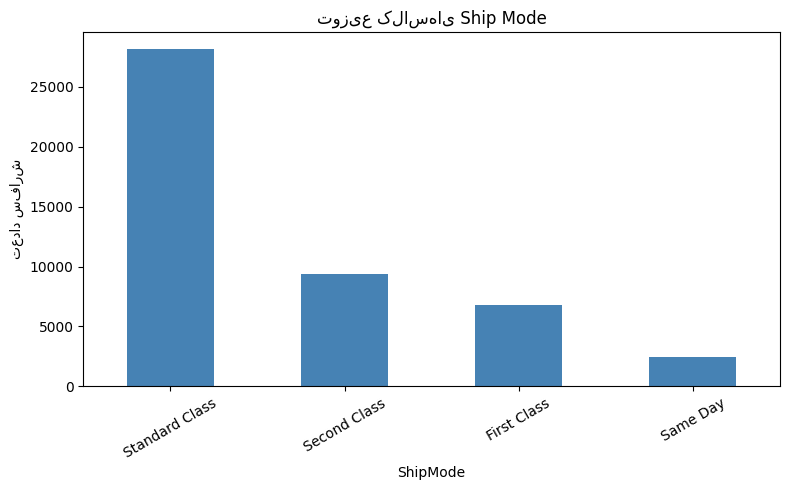

In [5]:
ax = df['ShipMode'].value_counts().plot(kind='bar', color='steelblue')
ax.set_title('توزیع کلاس‌های Ship Mode')
ax.set_ylabel('تعداد سفارش')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**نکته مهم:** همانطور که مشاهده می‌شود توزیع کلاس‌ها نامتوازن (imbalanced) است — Standard Class حدود ۶۰٪ داده‌ها را تشکیل می‌دهد. بنابراین علاوه بر accuracy، از **macro F1-score** هم برای ارزیابی مدل‌ها استفاده می‌کنیم تا عملکرد روی کلاس‌های کم‌تعداد (مثل Same Day) هم دیده شود.

## ۲. پیش‌پردازش داده‌ها و انتخاب ویژگی‌ها

In [6]:
# جدا کردن ویژگی‌ها (X) و هدف (y)
target_col = 'ShipMode'
X = df.drop(columns=[target_col])
y = df[target_col]

# شناسایی ستون‌های عددی و دسته‌ای
numeric_features = ['Sales', 'Quantity', 'Discount', 'Profit']
categorical_features = ['Market', 'Region', 'OrderPriority', 'Segment', 'Category', 'SubCategory']

print("ویژگی‌های عددی:", numeric_features)
print("ویژگی‌های دسته‌ای:", categorical_features)


ویژگی‌های عددی: ['Sales', 'Quantity', 'Discount', 'Profit']
ویژگی‌های دسته‌ای: ['Market', 'Region', 'OrderPriority', 'Segment', 'Category', 'SubCategory']


In [7]:
# انکود کردن برچسب هدف
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_
print("کلاس‌ها به ترتیب انکود شده:", list(class_names))


کلاس‌ها به ترتیب انکود شده: ['First Class', 'Same Day', 'Second Class', 'Standard Class']


In [8]:
# تقسیم داده به train و test (با حفظ نسبت کلاس‌ها - stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("اندازه‌ی train:", X_train.shape)
print("اندازه‌ی test:", X_test.shape)


اندازه‌ی train: (37352, 10)
اندازه‌ی test: (9338, 10)


In [9]:
# ساخت پایپ‌لاین پیش‌پردازش:
# - استانداردسازی ویژگی‌های عددی
# - One-Hot Encoding ویژگی‌های دسته‌ای
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


## ۳. آموزش و مقایسه‌ی چند الگوریتم

مدل‌های زیر آموزش داده می‌شوند:

| مدل | ویژگی |
|---|---|
| Logistic Regression | baseline ساده و سریع |
| Decision Tree | تفسیرپذیر، بدون نیاز به scale |
| Random Forest | ترکیب چند درخت، مقاوم به overfitting |
| K-Nearest Neighbors | مدل مبتنی بر شباهت نمونه‌ها |
| XGBoost | Gradient Boosting قدرتمند |
| LightGBM | Gradient Boosting سریع، مناسب داده‌های بزرگ |

برای مدل‌هایی که امکانش را دارند از `class_weight='balanced'` برای مقابله با عدم توازن کلاس‌ها استفاده می‌شود.

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=15),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                              eval_metric='mlogloss', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, max_depth=-1, learning_rate=0.1,
                                random_state=42, n_jobs=-1, verbose=-1),
}


In [11]:
results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 (macro)': round(f1_macro, 4),
        'F1 (weighted)': round(f1_weighted, 4)
    })
    trained_pipelines[name] = pipe
    print(f"{name} تمام شد | Accuracy={acc:.4f} | F1-macro={f1_macro:.4f}")


Logistic Regression تمام شد | Accuracy=0.5367 | F1-macro=0.3153


Decision Tree تمام شد | Accuracy=0.4706 | F1-macro=0.3184


Random Forest تمام شد | Accuracy=0.5872 | F1-macro=0.3297


KNN تمام شد | Accuracy=0.6063 | F1-macro=0.2901


XGBoost تمام شد | Accuracy=0.6283 | F1-macro=0.2918


LightGBM تمام شد | Accuracy=0.6236 | F1-macro=0.2966


## ۴. جدول مقایسه‌ی نتایج

In [12]:
results_df = pd.DataFrame(results).sort_values(by='F1 (macro)', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,F1 (macro),F1 (weighted)
0,Random Forest,0.5872,0.3297,0.5433
1,Decision Tree,0.4706,0.3184,0.4970
2,Logistic Regression,0.5367,0.3153,0.5223
3,LightGBM,0.6236,0.2966,0.5354
4,XGBoost,0.6283,0.2918,0.5342
5,KNN,0.6063,0.2901,0.5235


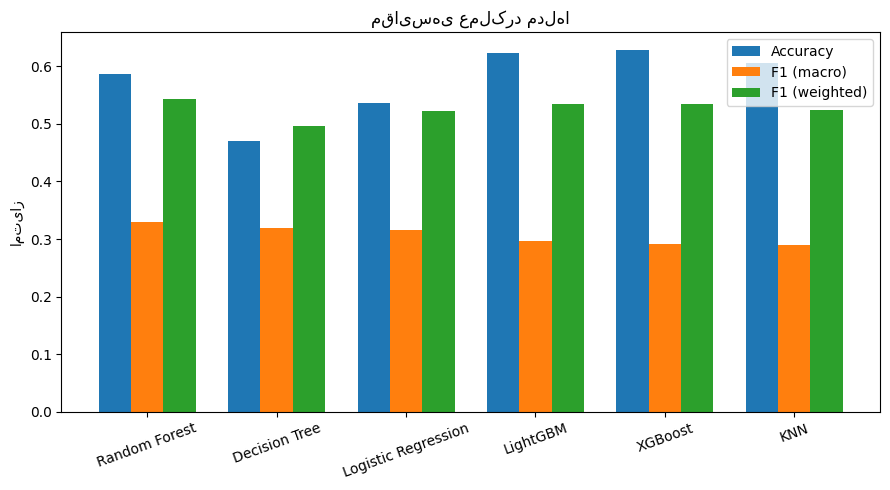

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
width = 0.25

ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy')
ax.bar(x, results_df['F1 (macro)'], width, label='F1 (macro)')
ax.bar(x + width, results_df['F1 (weighted)'], width, label='F1 (weighted)')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20)
ax.set_ylabel('امتیاز')
ax.set_title('مقایسه‌ی عملکرد مدل‌ها')
ax.legend()
plt.tight_layout()
plt.show()


## ۵. بررسی دقیق‌تر بهترین مدل

In [14]:
best_model_name = results_df.iloc[0]['Model']
best_pipeline = trained_pipelines[best_model_name]
y_pred_best = best_pipeline.predict(X_test)

print(f"بهترین مدل: {best_model_name}\n")
print(classification_report(y_test, y_pred_best, target_names=class_names))


بهترین مدل: Random Forest

                precision    recall  f1-score   support

   First Class       0.32      0.21      0.25      1351
      Same Day       0.16      0.06      0.09       490
  Second Class       0.28      0.17      0.21      1871
Standard Class       0.68      0.86      0.76      5626

      accuracy                           0.59      9338
     macro avg       0.36      0.33      0.33      9338
  weighted avg       0.52      0.59      0.54      9338



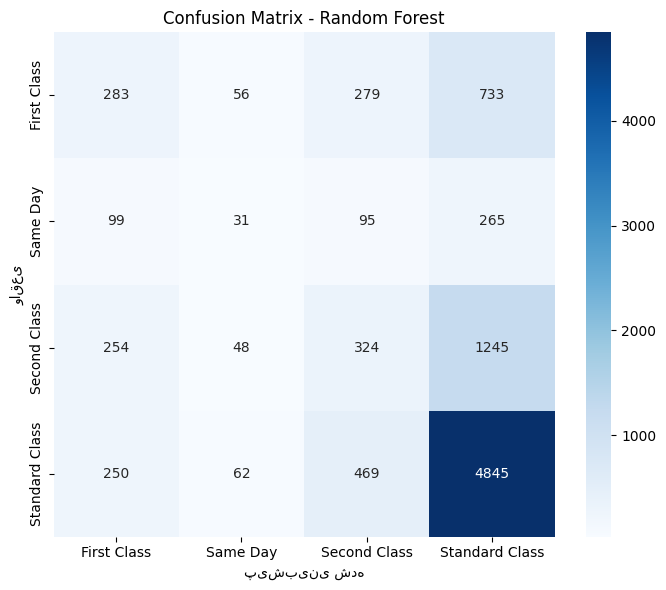

In [15]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('پیش‌بینی شده')
plt.ylabel('واقعی')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()


## ۶. اهمیت ویژگی‌ها (Feature Importance)

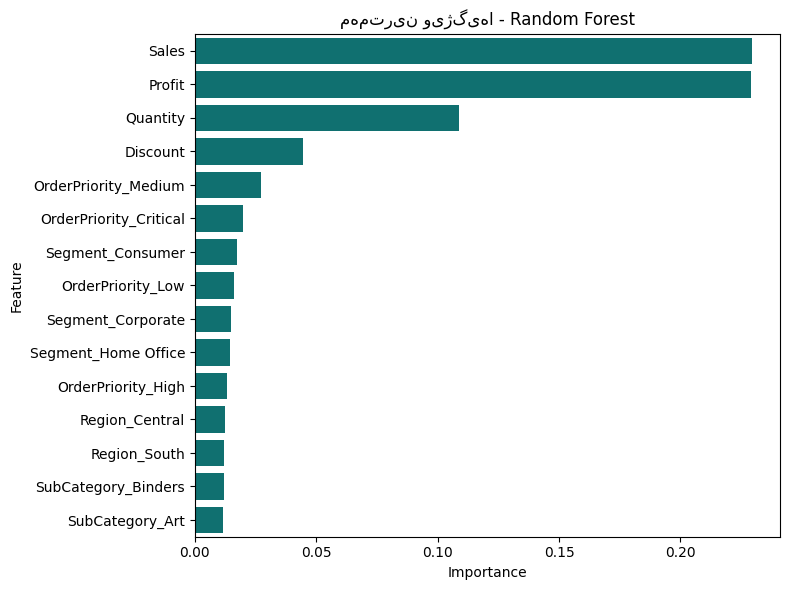

In [16]:
# استخراج نام ویژگی‌ها بعد از OneHotEncoding
ohe = best_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = list(ohe.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_feature_names

clf = best_pipeline.named_steps['classifier']

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances})
    imp_df = imp_df.sort_values(by='Importance', ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df, y='Feature', x='Importance', color='teal')
    plt.title(f'مهم‌ترین ویژگی‌ها - {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    print("این مدل feature_importances_ ندارد.")


## ۷. جمع‌بندی

- بهترین مدل بر اساس **F1-macro** (که به دلیل نامتوازن بودن کلاس‌ها معیار مناسب‌تری نسبت به accuracy است) در جدول بالا مشخص شد.
- مدل‌های مبتنی بر درخت و boosting (Random Forest, XGBoost, LightGBM) معمولاً روی داده‌های جدولی با ترکیب ویژگی عددی و دسته‌ای عملکرد بهتری نسبت به مدل‌های خطی و KNN دارند.
- برای بهبود بیشتر می‌توان: هایپرپارامترها را با GridSearch/Optuna تیون کرد، از تکنیک‌های resampling (مثل SMOTE) برای کلاس‌های کم‌تعداد استفاده کرد، یا ویژگی‌های جدید (feature engineering) مثل نسبت تخفیف به فروش ساخت.


## ۸. روش یادگیری عمیق (Deep Learning)

علاوه بر مدل‌های کلاسیک بالا، یک **شبکه‌ی عصبی چندلایه (Deep Neural Network / MLP)** با Keras/TensorFlow هم آموزش می‌دهیم تا ببینیم آیا می‌تواند الگوهای پیچیده‌تر و غیرخطی بین ویژگی‌ها را بهتر یاد بگیرد یا نه.

معماری شبکه:
- چند لایه‌ی Dense با تابع فعال‌سازی ReLU
- Batch Normalization برای پایداری آموزش
- Dropout برای جلوگیری از overfitting
- لایه‌ی خروجی Softmax برای طبقه‌بندی ۴ کلاسه
- وزن‌دهی کلاس‌ها (class_weight) برای مقابله با عدم توازن داده‌ها
- EarlyStopping برای جلوگیری از overfitting و انتخاب بهترین epoch

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

tf.random.set_seed(42)


I0000 00:00:1788268516.645961     681 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788268516.937224     681 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788268518.716928     681 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [18]:
# پیش‌پردازش داده برای شبکه‌ی عصبی (همان preprocessor قبلی: Scaling + OneHotEncoding)
X_train_nn = preprocessor.fit_transform(X_train, y_train)
X_test_nn = preprocessor.transform(X_test)

# اگر خروجی sparse بود، به آرایه‌ی معمولی تبدیل شود
if hasattr(X_train_nn, "toarray"):
    X_train_nn = X_train_nn.toarray()
    X_test_nn = X_test_nn.toarray()

n_features = X_train_nn.shape[1]
n_classes = len(class_names)
print("تعداد ویژگی‌های ورودی بعد از پیش‌پردازش:", n_features)
print("تعداد کلاس‌ها:", n_classes)


تعداد ویژگی‌های ورودی بعد از پیش‌پردازش: 51
تعداد کلاس‌ها: 4


In [19]:
# محاسبه‌ی وزن کلاس‌ها برای مقابله با imbalance
class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights_arr)}
print("وزن هر کلاس:", class_weight_dict)


وزن هر کلاس: {0: np.float64(1.727339992600814), 1: np.float64(4.764285714285714), 2: np.float64(1.2477284874398717), 3: np.float64(0.41498533463692117)}


In [20]:
def build_model(input_dim, num_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

dl_model = build_model(n_features, n_classes)
dl_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        13,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,516 (220.77 KB)

 Trainable params: 55,620 (217.27 KB)

 Non-trainable params: 896 (3.50 KB)

In [21]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
)

history = dl_model.fit(
    X_train_nn, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/100


  1/249 ━━━━━━━━━━━━━━━━━━━━ 8:11 2s/step - accuracy: 0.2109 - loss: 2.3684

 16/249 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2725 - loss: 1.9628 

 33/249 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2746 - loss: 1.8809

 52/249 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2846 - loss: 1.7976

...

184/249 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4885 - loss: 1.2024

205/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4898 - loss: 1.2011

226/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4895 - loss: 1.2016

246/249 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4897 - loss: 1.2019

249/249 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4896 - loss: 1.2027 - val_accuracy: 0.5070 - val_loss: 1.1826 - learning_rate: 5.0000e-04


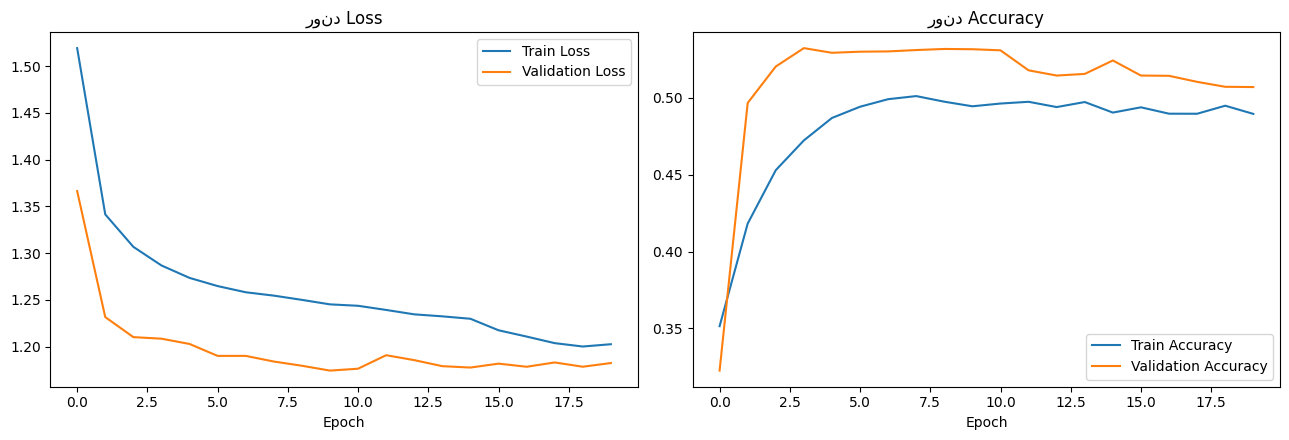

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('روند Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('روند Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


In [23]:
y_pred_dl_probs = dl_model.predict(X_test_nn)
y_pred_dl = np.argmax(y_pred_dl_probs, axis=1)

acc_dl = accuracy_score(y_test, y_pred_dl)
f1_macro_dl = f1_score(y_test, y_pred_dl, average='macro')
f1_weighted_dl = f1_score(y_test, y_pred_dl, average='weighted')

print(f"Deep Learning (MLP) | Accuracy={acc_dl:.4f} | F1-macro={f1_macro_dl:.4f} | F1-weighted={f1_weighted_dl:.4f}")
print()
print(classification_report(y_test, y_pred_dl, target_names=class_names))


  1/292 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step

 62/292 ━━━━━━━━━━━━━━━━━━━━ 0s 823us/step

124/292 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step

180/292 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step

244/292 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step

292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


Deep Learning (MLP) | Accuracy=0.5308 | F1-macro=0.3275 | F1-weighted=0.5266

                precision    recall  f1-score   support

   First Class       0.29      0.27      0.28      1351
      Same Day       0.11      0.43      0.17       490
  Second Class       0.27      0.07      0.10      1871
Standard Class       0.76      0.76      0.76      5626

      accuracy                           0.53      9338
     macro avg       0.35      0.38      0.33      9338
  weighted avg       0.56      0.53      0.53      9338



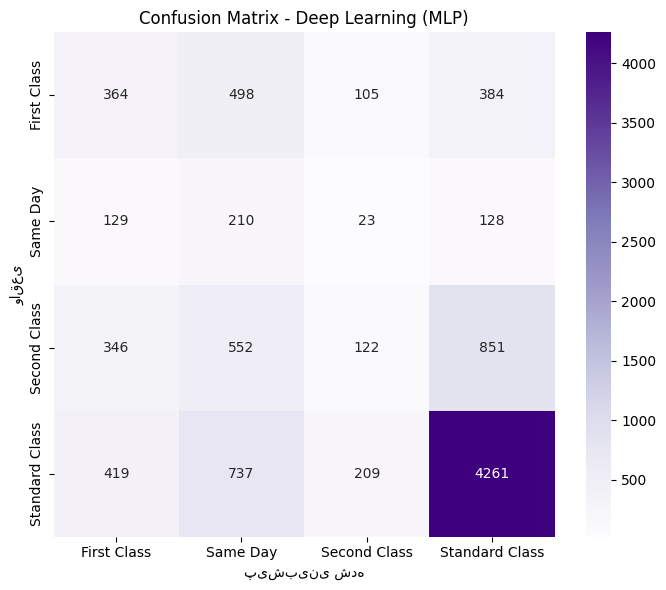

In [24]:
cm_dl = confusion_matrix(y_test, y_pred_dl)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Purples', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('پیش‌بینی شده')
plt.ylabel('واقعی')
plt.title('Confusion Matrix - Deep Learning (MLP)')
plt.tight_layout()
plt.show()


## ۹. مقایسه‌ی نهایی همه‌ی مدل‌ها (شامل Deep Learning)

In [25]:
dl_result = {
    'Model': 'Deep Learning (MLP)',
    'Accuracy': round(acc_dl, 4),
    'F1 (macro)': round(f1_macro_dl, 4),
    'F1 (weighted)': round(f1_weighted_dl, 4)
}

final_results_df = pd.concat([results_df, pd.DataFrame([dl_result])], ignore_index=True)
final_results_df = final_results_df.sort_values(by='F1 (macro)', ascending=False).reset_index(drop=True)
final_results_df


,Model,Accuracy,F1 (macro),F1 (weighted)
0,Random Forest,0.5872,0.3297,0.5433
1,Deep Learning (MLP),0.5308,0.3275,0.5266
2,Decision Tree,0.4706,0.3184,0.4970
3,Logistic Regression,0.5367,0.3153,0.5223
4,LightGBM,0.6236,0.2966,0.5354
5,XGBoost,0.6283,0.2918,0.5342
6,KNN,0.6063,0.2901,0.5235


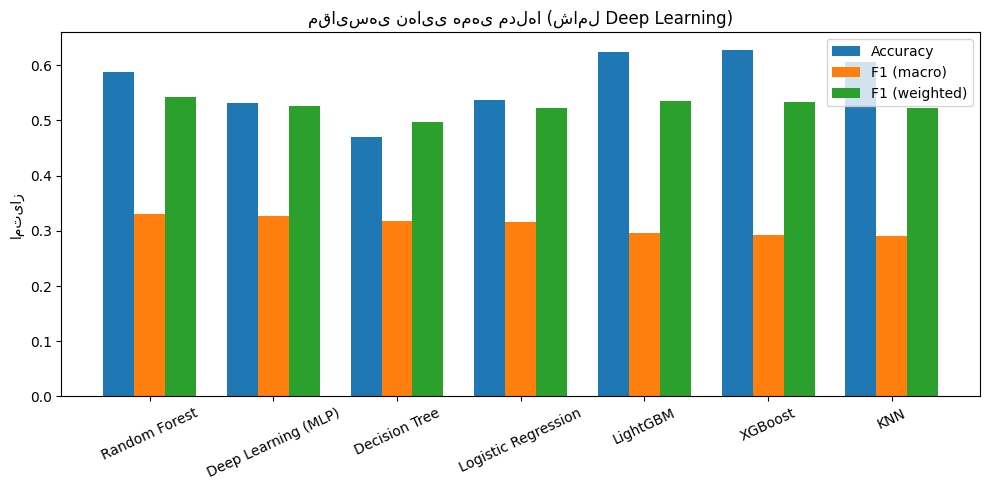

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(final_results_df))
width = 0.25

colors = ['#e63946' if m == 'Deep Learning (MLP)' else '#457b9d' for m in final_results_df['Model']]

ax.bar(x - width, final_results_df['Accuracy'], width, label='Accuracy')
ax.bar(x, final_results_df['F1 (macro)'], width, label='F1 (macro)')
ax.bar(x + width, final_results_df['F1 (weighted)'], width, label='F1 (weighted)')

ax.set_xticks(x)
ax.set_xticklabels(final_results_df['Model'], rotation=25)
ax.set_ylabel('امتیاز')
ax.set_title('مقایسه‌ی نهایی همه‌ی مدل‌ها (شامل Deep Learning)')
ax.legend()
plt.tight_layout()
plt.show()


## ۱۰. جمع‌بندی نهایی

نتایج نشان می‌دهد که آیا شبکه‌ی عصبی عمیق توانسته نسبت به مدل‌های کلاسیک (به‌خصوص Random Forest و LightGBM/XGBoost) عملکرد بهتری داشته باشد یا نه.

نکات مهم:
- شبکه‌ی عصبی به داده‌ی بیشتر و tuning دقیق‌تر (تعداد لایه، نورون، dropout، learning rate) برای رسیدن به بهترین عملکرد نیاز دارد.
- با توجه به این‌که ویژگی‌های موجود ارتباط ذاتاً ضعیفی با ShipMode دارند (همان‌طور که در مدل‌های قبلی هم دیدیم)، احتمالاً یادگیری عمیق هم به یک سقف مشابه محدود می‌شود، مگر این‌که ویژگی‌های جدید و قوی‌تری (feature engineering) اضافه شود.
- برای بهبود بیشتر: افزایش عمق شبکه، استفاده از Embedding برای ویژگی‌های دسته‌ای پرتنوع (مثل SubCategory) به‌جای OneHot، و هایپرپارامتر تیونینگ (Keras Tuner) پیشنهاد می‌شود.